In [1]:
# import all the E9 stuff
import logging
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch
import sys
from pathlib import Path
import time
from scipy.linalg import eigh
from collections import defaultdict
# import scienceplots

# plt.style.use(['nature'])
# Nature
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']

# 2. Tell the math engine to use custom fonts instead of LaTeX fonts
plt.rcParams['mathtext.fontset'] = 'custom'

# 3. Assign Arial to the standard math modes (for numbers and variables inside $...$)
plt.rcParams['mathtext.rm'] = 'Arial'         # Roman (normal) math text
plt.rcParams['mathtext.it'] = 'Arial:italic'  # Italic math text
plt.rcParams['mathtext.bf'] = 'Arial:bold'    # Bold math text
# plt.rcParams['pdf.fonttype'] = 42               # can't do this here because it doesn't handle vectors
# plt.rcParams['ps.fonttype'] = 42  # Do the same if you ever save to .eps

# User defined modules
E9path = Path("C:/", "Users", "ken92", "Documents", "Studies", "E5", "simulation", "E9_simulations")
if str(E9path) not in sys.path:
    sys.path.insert(1, str(E9path))
import E9_fn.E9_constants as E9c
import E9_fn.E9_atom as E9a
import E9_fn.E9_cooltrap as E9ct
import E9_fn.plane_wave_expansion.blochstate_class as bsc
# import E9_fn.polarizabilities_calculation as E9pol
# import E9_fn.datasets.transition_line_data as TLData
from E9_fn import util

# Logging

logpath = '' # '' if not logging to a file
loglevel = logging.INFO
logroot = logging.getLogger()
list(map(logroot.removeHandler, logroot.handlers))
list(map(logroot.removeFilter, logroot.filters))
logging.basicConfig(filename = logpath, level = loglevel)

c:\Users\ken92\Documents\Studies\E5\simulation\E9_simulations\.venv\Lib\site-packages\gftool\precision.py:16: UserWarning: No quad precision datatypes available!
Some functions might be less accurate.
  warnings.warn("No quad precision datatypes available!\n"


# Inputs

In [2]:
species = "K40" # "Rb87", "K40"

# lattice parameters
# V1064Er = 0.5            # 1064 lattice depth, in 1064 recoil energy
# V532Er = 2.             # 532 lattice depth, in 532 recoil energy
# Rb kHz to Er
# V1064Er = 20. / 2.02781   # 25.213063
# V532Er = 0. / 8.11125    # 35.517929
# K kHz to Er
V1064Er = 39.5 / 4.4099   # 39.5
V532Er = 0. / 17.6394    # 35.517929
n0nom = 0               # peak density
# The superlattice phase that determines the relative position between 1064 and 532 lattice
# 532 lattice is fixed at 0, so changing the pase by pi for 1064 restores the original lattice
phi12, phi23 = 0., 0.
# phi12, phi23 = np.pi/2, 0.
# phi12, phi23 = 0., np.pi/2
# phi12, phi23 = np.pi*1/3, -np.pi*1/3    # decorated triangular lattice (2/3 also works)
# phi12, phi23 = np.pi*4e-3, -np.pi*4e-3    # decorated triangular lattice
ABoffset1064nom = 0     # max 0.011585 * V1064nom / 9 / np.sqrt(3) for Rb
B1_rel_int_1064 = 1     # relative intensity (field is sqrt of that) of 1064 B1
B1_rel_int_532  = 1     # relative intensity (field is sqrt of that) of 532 B1
B3_rel_int_1064 = 1     # relative intensity (field is sqrt of that) of 1064 B3
B3_rel_int_532  = 1     # relative intensity (field is sqrt of that) of 532 B3

# Basic simulation parameters
num = 6             # size of q-momentum space we consider: (-num, num) (usually 5)
k_center = (0, 0)
bandstart = 0       # starting from 0, inclusive
bandend = 4         # inclusive
# qverts_str = 'np.array([0.4, -0.4]), np.array([0.4, 0.4]), np.array([-0.4, 0.4]), np.array([-0.4, -0.4]), np.array([0.4, -0.4])'
# qverts_str = 'E9c.Kp4/E9c.k_lw, E9c.Gp/E9c.k_lw, E9c.Kp/E9c.k_lw, E9c.Mp/E9c.k_lw, E9c.Gp/E9c.k_lw'
# qverts_str = 'E9c.Kp/E9c.k_lw, E9c.Kp2/E9c.k_lw, E9c.Kp3/E9c.k_lw, E9c.Kp4/E9c.k_lw, E9c.Kp5/E9c.k_lw, E9c.Kp6/E9c.k_lw, E9c.Kp/E9c.k_lw'
# x_ticklist = ["K'", '$\Gamma$', 'K', 'M', '$\Gamma$']
qverts_str = 'E9c.Gp/E9c.k_lw, E9c.Kp/E9c.k_lw, E9c.Mp/E9c.k_lw, E9c.Gp/E9c.k_lw'
x_ticklist = ['$\Gamma$', 'K', 'M', '$\Gamma$']
save_results = False

# Initialization
## Units

In [3]:
if species == "Rb87":
    all_units_dict = E9c.all_lat_unit_Rb87
    Er_1064 = E9c.E_r1064_Rb87
    Er_532 = E9c.E_r532_Rb87
elif species == "K40":
    all_units_dict = E9c.all_lat_unit_K40
    Er_1064 = E9c.E_r1064_K40
    Er_532 = E9c.E_r532_K40
else:
    raise ValueError("Unknown species: {}".format(species))
m_unit = all_units_dict["m_unit"]
l_unit = all_units_dict["l_unit"]
E_unit = all_units_dict["E_unit"]
f_unit = all_units_dict["f_unit"]
t_unit = all_units_dict["t_unit"]

V532nom = V532Er * Er_532 / E9c.hnobar / 1e3       # in kHz (i.e. V_SI / hbar / 1e3 / 2pi), assuming that polarizability is accounted for correctly
V1064nom = V1064Er * Er_1064  / E9c.hnobar / 1e3   # Note that setting this to 0 doesn't give you a proper band structure of 532 nm lattice, since you are now
                                # considering too many plane waves that don't actually contribute.
V532 = 2 * np.pi * V532nom * 1e3 / f_unit   # 2 * np.pi because I have f = E/hbar instead of E/h as normally defined
V1064 = 2 * np.pi * V1064nom * 1e3 / f_unit
ABoffset1064 = 2 * np.pi * ABoffset1064nom * 1e3 / f_unit
n0 = n0nom * l_unit**3

In [4]:
Exp_lib = {"species": species, "units_dict": all_units_dict
        , 'V532nom': V532nom, 'V1064nom': V1064nom, 'V532': V532, 'V1064': V1064
        , 'B1_rel_int_532': B1_rel_int_532, 'B1_rel_int_1064': B1_rel_int_1064 , 'B3_rel_int_532': B3_rel_int_532, 'B3_rel_int_1064': B3_rel_int_1064
        , 'n0nom': n0nom, 'n0': n0
        , 'ABoffset1064nom': ABoffset1064nom, 'ABoffset1064': ABoffset1064
        , 'phi12': phi12, 'phi23': phi23}

size = 2 * num + 1
bandnum = bandend - bandstart + 1 # number of bands interested in
qverts_arr = eval(qverts_str)

In [5]:
def MinimumGap(e_values, band1, band2):
    """Prints the position and energy of the minimum gap.
    
    Example: MinimumGap(e_values,2,3)
    Should be slightly enhanced to return something
    """
    gaps = e_values[:, band2] - e_values[:, band1]
    print('The minimum band gap between band{} and band{} is {} kHz, happening at the {} (python index) q evaluated' \
          .format(band1, band2, gaps.min() * f_unit / 1e3 / (2 * np.pi), gaps.argmin()))

# Real space plots

Pretty sure that the orientation is still wrong - maybe flipped about $x = 0$?

In [6]:
bool_plot_real = True
x_real = np.linspace(-1, 1, 500) * 1e-6
y_real = np.linspace(-1.1, 1.1, 500) * 1e-6

C:\Users\ken92\AppData\Local\Temp\ipykernel_26904\1398260329.py:17: RuntimeWarning: invalid value encountered in divide
  alpha = V_real / np.nanmax(V_real)


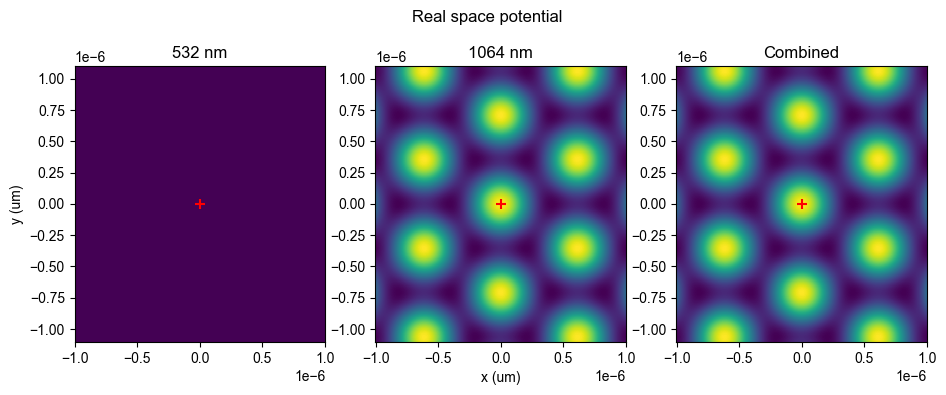

In [7]:
pos_delta = E9c.l_cell_lw * E9c.k1k * (phi12 / 2 / np.pi) + E9c.l_cell_lw * E9c.k3k * (phi23 / 2 / np.pi)
x_delta, y_delta = pos_delta # should be simple functions of phi12 and phi23
V_532_real = bsc.get_Vin(x_real, y_real, V532, B1_rel_int_532, B3_rel_int_532, 0, 0, 1)
V_1064_real = - bsc.get_Vin(x_real, y_real, V1064, B1_rel_int_1064, B3_rel_int_1064, x_delta, y_delta, 2)
V_super_real = V_532_real + V_1064_real
fig_real = plt.figure(figsize = (11, 4))
ax_532 = fig_real.add_subplot(131, aspect = "equal")
ax_1064 = fig_real.add_subplot(132, aspect = "equal")
ax_super = fig_real.add_subplot(133, aspect = "equal")
fig_real.suptitle("Real space potential")
ax_532.set_ylabel("y (um)")
ax_1064.set_xlabel("x (um)")
if bool_plot_real:
    for ax, V_real, ax_title in zip([ax_532, ax_1064, ax_super],
                                    [V_532_real, V_1064_real, V_super_real],
                                    ["532 nm", "1064 nm", "Combined"],):
        alpha = V_real / np.nanmax(V_real)
        im = ax.pcolormesh(x_real, y_real, V_real, cmap = 'viridis')
        ax.scatter(0, 0, color = 'red', marker = '+', s = 50)
        ax.set_title(ax_title)
        # fig_real.colorbar(im, ax = ax)
    

# Finding Bloch states and band energies

In [8]:
rq_circ = 0.65625
dq = 0.65625 * 2 * np.pi / 360

In [9]:
start_time = time.time()

# Generate qset
num_points = int(2. * np.pi * rq_circ / dq)
qsets, xq = bsc.find_qset_circle(E9c.Gp/E9c.k_lw, rq_circ, theta_init = np.pi + 0.001, pt_num = num_points)

e_values = np.zeros((len(qsets), bandnum), dtype = np.cdouble)
e_states = np.zeros((len(qsets), size**2, bandnum), dtype = np.cdouble)
e_states_ni = [[] for _ in range(bandnum)]  # a list of blochstate for each band

# find non-interacting solution
print("Total number of points = {0}".format(len(qsets)))
Hq_mmat, Hq_nmat, H_532, H_1064 = bsc.find_H_components(num, Exp_lib, center = k_center)
for i in range(len(qsets)):
    H = bsc.find_H(qsets[i], Exp_lib, Hq_mmat, Hq_nmat, H_532, H_1064)
    e_values[i,:], e_states[i,:,:] = eigh(H, eigvals = (bandstart, bandend),
                                          overwrite_a = True, check_finite = False)

# Fix the gauge of eigenstates using parallel transport
e_states_fixed = bsc.fix_gauge_parallel_transport_1d(e_states, flip_gauge_for_bands = [0])
for i in range(len(qsets)):
    for j, bandN in enumerate(range(bandstart, bandend + 1)):
        e_states_ni[j].append(bsc.blochstate(e_states[i,:,j], q = qsets[i], center = k_center, N = bandN, E = e_values[i,j], param = Exp_lib))
print("--- {0} seconds ---".format((time.time() - start_time)))


Total number of points = 360
--- 91.47258996963501 seconds ---


## Fig. 2a
Added so many things that this deserves its own block.

In [10]:
str_journal = "BIGGUS"  # for screen display
str_journal = "nature"

mm2inch = 1 / 25.4
plt_sizes_all_journals = {
    "nature": {
        "fig_BZ_figsize":       np.array([30, 30]) * mm2inch,

        "BZ_lw":                0.5,
        "BZ_q_pt_s_scat":       0.6,
        "sym_pt_fontsize":      6,
        "q_circ_lw":            1,
        "q_circ_arrowstyle":    '-|>,head_width=0.02,head_length=0.05',

        "theta_PM_--lw":        0.7,
        "theta_PM_arclw":       0.6,
        "theta_PM_fontsize":    7,
        "PM_arrow_stem_lw":     1.,
        "PM_arrow_arrowstyle":  '<|-|>,head_width=0.03,head_length=0.04',

        "coor_arrow_lw":        1,
        "coor_arrowstyle":      '-|>,head_width=0.02,head_length=0.03',
        "coor_fontsize":        6,

        # Berry connection plot
        "fig_Berry_figsize":    np.array([30, 30]) * mm2inch,

        "A12_circ_lw":          1,
        "A12_circ_arrowstyle":  '-|>,head_width=0.03,head_length=0.1',
        "quiver_lw":            0.3,
        "A12_text_fontsize":    7,
        "r_circ_scale":         0.8,

        # Berry connection with words plot
        "fig_Berryw_figsize":   np.array([40, 22]) * mm2inch,
    },
    "BIGGUS": {
        "fig_BZ_figsize":       np.array([5, 4.5]),

        "BZ_lw":                2,
        "BZ_q_pt_s_scat":       64,
        "sym_pt_fontsize":      30,
        "q_circ_lw":            3,
        "q_circ_arrowstyle":    '-,head_width=0.08,head_length=0.16',

        "theta_PM_--lw":        2.5,
        "theta_PM_arclw":       1.8,
        "theta_PM_fontsize":    32,
        "PM_arrow_stem_lw":     4,
        "PM_arrow_arrowstyle":  '<|-|>,head_width=0.14,head_length=0.26',

        "coor_arrow_lw":        3,
        "coor_arrowstyle":      '-|>,head_width=0.05,head_length=0.12',
        "coor_fontsize":        30,

        # Berry connection plot
        "fig_Berry_figsize":    np.array([5, 5]),

        "A12_circ_lw":          5,
        "A12_circ_arrowstyle":  '-|>,head_width=0.2,head_length=0.55',
        "quiver_lw":            1.5,
        "A12_text_fontsize":    50,
        "r_circ_scale":         1.,
    }
}

plt_sizes = plt_sizes_all_journals[str_journal]

For nature submission


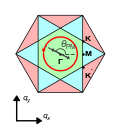

In [11]:
# BZ plot
print(f"For {str_journal} submission")

fig_BZ, ax_BZ = plt.subplots(1, 1, figsize = plt_sizes["fig_BZ_figsize"])
bsc.PlotBZSubplot(ax_BZ, N_BZ = 3, BZ_kwargs = {"lw": plt_sizes["BZ_lw"]},
                  add_q_pts = False, s_q_pt = plt_sizes["BZ_q_pt_s_scat"],
                  label_sym_pts = True, fontsize = plt_sizes["sym_pt_fontsize"])
bsc.plot_qset_circle_arrow(ax_BZ, qset = qsets,
                           line_kwargs = {"linewidth": plt_sizes["q_circ_lw"]},
                           arrow_kwargs = {"mutation_scale": 70,
                                           "arrowstyle": plt_sizes["q_circ_arrowstyle"]})
ax_BZ.axis("off")

# Add definition of \theta_{PM}
color_theta_PM = "#444444"
hline_endpt = rq_circ * E9c.Mp4 / E9c.k_lw
theta_PM_example = np.pi * 8.5 / 10
theta_endpt = rq_circ * np.array([np.cos(theta_PM_example), np.sin(theta_PM_example)])
theta_arrow_endpt = 0.7 * theta_endpt
theta_stem_endpt = 0.45 * theta_endpt

ax_BZ.plot([0, hline_endpt[0]], [0, hline_endpt[1]],
           color = color_theta_PM, linestyle = "--", linewidth = plt_sizes["theta_PM_--lw"])
ax_BZ.plot([0, theta_endpt[0]], [0, theta_endpt[1]],
           color = color_theta_PM, linestyle = "--", linewidth = plt_sizes["theta_PM_--lw"])
util.draw_circle(ax_BZ, center = (0, 0), radius = 0.2, theta_range = (0, theta_PM_example),
                 close_circle = False, color = color_theta_PM, linestyle = "-", linewidth = plt_sizes["theta_PM_arclw"])
ax_BZ.text(0., 0.25, r"$\theta_{\mathrm{PM}}$", color = color_theta_PM, fontsize = plt_sizes["theta_PM_fontsize"])
ax_BZ.plot([- theta_stem_endpt[0], theta_stem_endpt[0]], [- theta_stem_endpt[1], theta_stem_endpt[1]],
           color = color_theta_PM, linestyle = "-", linewidth = plt_sizes["PM_arrow_stem_lw"])
arrow_PM = FancyArrowPatch(
                theta_arrow_endpt,
                -theta_arrow_endpt,
                edgecolor = "none",         # This smoothes out the arrow
                facecolor = color_theta_PM,
                arrowstyle = plt_sizes["PM_arrow_arrowstyle"],
                mutation_scale = 50,
                shrinkA = 0,
                shrinkB = 0
            )
ax_BZ.add_patch(arrow_PM)

# orientation
coor_pos = np.array([-1.7, -2.6])
x_axis_tip = np.array([1, 0]) + coor_pos
y_axis_tip = np.array([0, 1]) + coor_pos
for p1 in (x_axis_tip, y_axis_tip):
    arrow = FancyArrowPatch(
        coor_pos, p1,
        edgecolor = "black",
        facecolor = "black",
        linewidth = plt_sizes["coor_arrow_lw"],
        arrowstyle = plt_sizes["coor_arrowstyle"],
        mutation_scale = 100,
        shrinkA = 0,
        shrinkB = 0
    )
    ax_BZ.add_patch(arrow)
ax_BZ.text(*x_axis_tip + np.array([0., 0.1]), r"$q_x$", fontsize = plt_sizes["coor_fontsize"])
ax_BZ.text(*y_axis_tip + np.array([0.2, -0.2]), r"$q_y$", fontsize = plt_sizes["coor_fontsize"])

fig_BZ.tight_layout(pad = 0)

# Save
fig2apath = Path(r"C:\Users\ken92\Documents\Studies\E5\simulation\E9_simulations\projects\band_spectroscopy\paper_figures\fig2",
                 f"fig2a_{str_journal}.svg")
# fig_BZ.savefig(fig2apath, format = "svg", facecolor = "none")

In [12]:
if not np.all(np.isreal(e_values)):
    logging.warning('Complex eigenvalue detected. Imaginary parts are discarded.')
e_values = e_values.astype(np.double)

if save_results:
    path_str = "simulation_results\\" #IF NOT WORKING: CHANGE TO FULL PATH NAME // TRY ADDING FULL PATH TO "PYTHONPATH manager"
    suffix_str = "_honeycomb_NearG_20210826"
    sim_str = "e_values_ni_{0}_{1}_{2}_k{3}{3}_{4}{5}".format(
                V532nom, V1064nom, n0nom, num, k_center[0], k_center[1])
    bsc.SaveStateList(path_str + sim_str + suffix_str, e_states_ni)

C:\Users\ken92\AppData\Local\Temp\ipykernel_26904\1552478050.py:3: ComplexWarning: Casting complex values to real discards the imaginary part
  e_values = e_values.astype(np.double)


## Plots

### Band structure

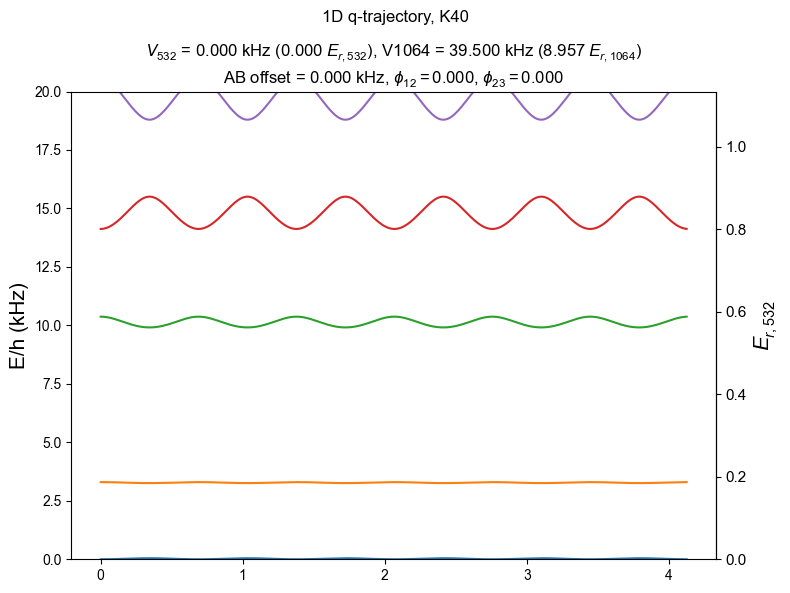

In [13]:
E2kHz = E_unit / E9c.hnobar / 1e3 # conversion factor from natural units to kHz
E_lowest = np.min(e_values)
E_kHz_offset = (e_values - E_lowest) * E2kHz
E_kHz_highest = np.max(E_kHz_offset)
E_plot_kHz = (e_values.transpose() - E_lowest) * E2kHz

fig_E = plt.figure(0, figsize=(8,6))
fig_E.clf()

ax_E = fig_E.add_subplot(111)
for i in range(bandnum):
    ax_E.plot(xq, E_plot_kHz[i], '-', label = 'Non-interacting' + str(i + bandstart))
ryax = ax_E.secondary_yaxis('right', functions = (lambda x: x / (E2kHz * 2 * np.pi**2), lambda x: x * (E2kHz * 2 * np.pi**2)))
ryax.set_ylabel(r"$E_{r,532}$", fontsize = 15)
ryax.tick_params(axis = 'y', labelsize = 11)
ax_E.set_ylabel('E/h (kHz)', fontsize = 15)
# ax_E.set_xticks(xq[index_points], x_ticklist, fontsize = 14)
ax_E.set_title((rf'$V_{{532}}$ = {V532nom:.3f} kHz (${V532Er:.3f}\ E_{{r, 532}}$), V1064 = {V1064nom:.3f} kHz (${V1064Er:.3f}\ E_{{r, 1064}}$)'
                '\n'
                rf'AB offset = {float(ABoffset1064nom):.3f} kHz, $\phi_{{12}} = {phi12:.3f}$, $\phi_{{23}} = {phi23:.3f}$'))
ax_E.set_ylim(0, 20)

fig_E.suptitle(f'1D q-trajectory, {species}')
fig_E.tight_layout()

## Bloch state
### Population in each peak
I use the ground state to visualize the peak that I'm looking at.

In [14]:
color_B12 = np.array([1, 0, 0])      # Colors in an array of [R, G, B] for easier numerical manipulation
color_B23 = np.array([0, 1, 0])
color_B13 = np.array([0, 0, 1])
color_center = np.array([0, 0, 0])
color_else = np.array([0, 0, 0])
# This is arranged in the order of [G1, G2, G3]
all_colors = np.vstack([color_B23, color_B13, color_B12])

dict_diff_order = {
    "center": np.array([0, 0, 0]),
    "G1_1st": np.array([1, 0, 0]),
    "G2_1st": np.array([0, 1, 0]),
    "G3_1st": np.array([0, 0, 1]),
    "G1_2nd": np.array([2, 0, 0]),
    "G2_2nd": np.array([0, 2, 0]),
    "G3_2nd": np.array([0, 0, 2]),
    "G1_G2": np.array([1, -1, 0]),  # This is G1_1st - G2_1st; other pairs follows similarly
    "G2_G3": np.array([0, 1, -1]),
    "G3_G1": np.array([-1, 0, 1]),
}

hw_mn = np.array([E9c.k_lw * 0.3, E9c.k_lw * 0.3])    # half width of the box that encloses each peak

C:\Users\ken92\Documents\Studies\E5\simulation\E9_simulations\E9_fn\plane_wave_expansion\blochstate_class.py:487: ComplexWarning: Casting complex values to real discards the imaginary part
  vec = vec.astype(float)


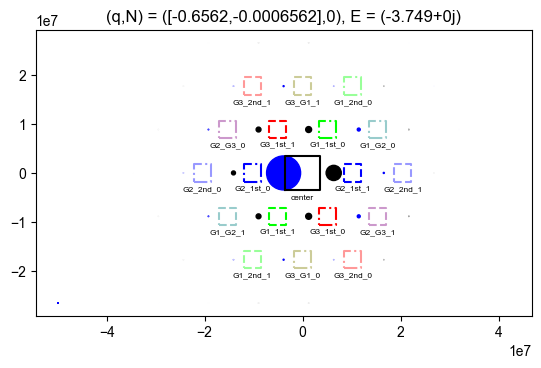

In [15]:
psi_gs = e_states_ni[0][0]  # Just need a whatever state
dict_color_pairs = {"center": color_center, "everything else": color_else}
ax_gs = bsc.ToFSubplot(psi_gs)

# center peak
util.plot_rectangle(ax_gs, center = psi_gs.q, half_widths = hw_mn * 2,
                    color = color_center, ls = "-")
ax_gs.text(psi_gs.q[0], psi_gs.q[1] - E9c.k_lw * 0.9, 'center',
            fontsize = 6, horizontalalignment = 'center', color = 'k')

# diffraction peaks
for label_pair, diff_order in dict_diff_order.items():
    if label_pair == "center": continue
    m_diff = diff_order[0] - diff_order[2]
    n_diff = diff_order[1] - diff_order[2]

    num_of_diff = abs(diff_order).sum()
    color = abs(diff_order) @ all_colors / num_of_diff
    dict_color_pairs[label_pair] = color
    alpha = 1 - np.sqrt(num_of_diff - 1) * 0.6

    for i_pk, ls_pk in zip([0, 1], ["-.", "--"]):
        vec = ((m_diff * E9c.G1 + psi_gs.q[0]) +
               (n_diff * E9c.G2 + psi_gs.q[1])) * (-1)**i_pk
        util.plot_rectangle(ax_gs, center = vec, half_widths = hw_mn,
                            color = color, alpha = alpha, ls = ls_pk)
        ax_gs.text(vec[0], vec[1] - E9c.k_lw * 0.6, label_pair + f'_{i_pk}',
                   fontsize = 6, horizontalalignment = 'center', color = 'k')

### Ratio of population in the 0th order point at each point
We currently call this the "participation ratio" just so that it has a name.

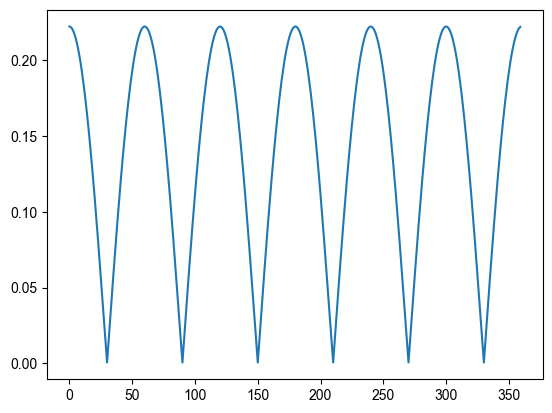

In [16]:
mn00_band0 = np.array([abs(psi.mnasindex(0, 0)) for psi in e_states_ni[0]])
mn00_band1 = np.array([abs(psi.mnasindex(0, 0)) for psi in e_states_ni[1]])
mn00_ratio_band10 = mn00_band1 / mn00_band0
plt.plot(mn00_ratio_band10)

# Interband Berry conections
I calculate all the connections within the given range of bands.
## Finding $A_{mn}$

In [17]:
# For example, A_01(q = qsets[i_q]) = inter_Berry_conns[i_q, 0, 1, :]
# To avoidA_10(q = qsets[i_q]) = inter_Berry_conns[i_q, 0, 1, :]
inter_Berry_conns = np.zeros((len(qsets), bandnum, bandnum, 2), dtype = np.float128)

for i in range(len(qsets)):
    for i_lower in range(bandnum):
        for i_higher in range(i_lower + 1, bandnum):
            psi1, psi2 = e_states_fixed[i, :, i_lower], e_states_fixed[i, :, i_higher]
            E12 = e_values[i, i_higher] - e_values[i, i_lower]
            inter_Berry_conns[i, i_lower, i_higher, :] = bsc.find_inter_Berry_conn(qsets[i], psi1, psi2, E12, Exp_lib, Hq_mmat, Hq_nmat)

inter_Berry_conns_mag = np.linalg.norm(inter_Berry_conns, axis = 3)

C:\Users\ken92\AppData\Local\Temp\ipykernel_26904\1270803215.py:10: ComplexWarning: Casting complex values to real discards the imaginary part
  inter_Berry_conns[i, i_lower, i_higher, :] = bsc.find_inter_Berry_conn(qsets[i], psi1, psi2, E12, Exp_lib, Hq_mmat, Hq_nmat)


$A_{mn}$ has the units of length. l_unit is 532nm in my code.

In [18]:
np.percentile(inter_Berry_conns_mag[:,0,3], 50) * (l_unit / E9c.a_lw_hex)

np.longdouble('0.11155910213357408')

## Plots

In [19]:
i_Berry = (0, 1)            # The bands between which the A_mn is plotted
alpha_pwr = 1 / 3
quiver_interval = len(qsets) // 24

In [20]:
A_Berry = inter_Berry_conns[:, *i_Berry, :] # Interband Berry connection of the selected bands
A_mag = inter_Berry_conns_mag[:, *i_Berry]  # Magnitude of A_Berry
A_theta = np.arctan2(A_Berry[:,1], A_Berry[:,0])
A_plot = A_Berry / A_mag[:, np.newaxis]     # Normalized A_Berry for the direction plot

A_mag = np.nan_to_num(A_mag, nan = 0., posinf = 1.)
logA_mag = np.log(A_mag)   # note: row = y, col = x

INFO:matplotlib.mathtext:Substituting symbol \combiningrightarrowabove from Computer Modern
INFO:matplotlib.mathtext:Substituting symbol \combiningrightarrowabove from Computer Modern


For nature submission


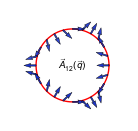

In [21]:
# Visualize A_01(q) as a vector field over the BZ
print(f"For {str_journal} submission")

fig_Berry, axes_Berry = plt.subplots(1, 1, figsize = plt_sizes["fig_Berry_figsize"])
axes_Berry = [axes_Berry]

# Normalize magnitudes into [0,1] for alpha
A_mag_finite = A_mag[np.isfinite(A_mag)]
if np.nanmax(A_mag_finite) > 0:
    alpha_vals = np.nan_to_num(A_mag / A_mag_finite.max(), nan = 0., posinf = 1., neginf = 1.)
else:
    alpha_vals = np.zeros_like(A_mag)

# Vector field plots
# Build RGBA colors with alpha = amplitude
base_color = (0.1, 0.2, 0.8)  # e.g. blue-ish
colors_rgba = np.zeros((len(A_mag), 4))
colors_rgba[:, 0] = base_color[0]
colors_rgba[:, 1] = base_color[1]
colors_rgba[:, 2] = base_color[2]
colors_rgba[:, 3] = alpha_vals**alpha_pwr

quiver_scale = dq / 0.02
qsets_scaled = qsets * plt_sizes["r_circ_scale"]
axes_Berry[0].quiver(
    qsets_scaled[::quiver_interval, 0], qsets_scaled[::quiver_interval, 1],
    A_plot[::quiver_interval, 0], A_plot[::quiver_interval, 1],
    color = colors_rgba,
    edgecolor = "black", linestyle = "-", linewidth = plt_sizes["quiver_lw"],
    angles = 'xy', scale_units = 'xy', scale = 10 * quiver_scale,
    width = 0.02 * quiver_scale,
    zorder = 100
)
# bsc.plot_qset_circle_arrow(axes_Berry[0], qset = qsets_scaled[1:], line_kwargs = {"linewidth": plt_sizes["A12_circ_lw"]},
#                            arrow_kwargs = {"arrowstyle": plt_sizes["A12_circ_arrowstyle"]})
util.draw_circle(axes_Berry[0], np.array([0, 0]), np.linalg.norm(qsets_scaled[0]),
                 color = "red", linewidth = plt_sizes["A12_circ_lw"])
# axes_Berry[0].set_title(rf"Direction of $A_{{{i_Berry}}}(q)$ ($\alpha \propto |A|^{{{alpha_pwr:.2f}}}$)")
# axes_Berry[0].set_xlabel(r"$q_x$")
# axes_Berry[0].set_ylabel(r"$q_y$")
axes_Berry[0].set_aspect('equal')
axes_Berry[0].set_xlim(-0.9, 0.8)
axes_Berry[0].set_ylim(-0.8, 0.8)
axes_Berry[0].axis("off")
axes_Berry[0].text(0, 0, r"$\vec{A}_{12}(\vec{q})$",
                   fontsize = plt_sizes["A12_text_fontsize"], va = "center", ha = "center")

fig_Berry.tight_layout(pad = 0)

fig2bpath = Path(r"C:\Users\ken92\Documents\Studies\E5\simulation\E9_simulations\projects\band_spectroscopy\paper_figures\fig2",
                 f"fig2b_{str_journal}.pdf")
# fig_Berry.savefig(fig2bpath, format = "pdf", facecolor = "none", dpi = 300)

For nature submission


INFO:matplotlib.mathtext:Substituting symbol \combiningrightarrowabove from Computer Modern
INFO:matplotlib.mathtext:Substituting symbol \propto from Computer Modern
INFO:matplotlib.mathtext:Substituting symbol \combiningrightarrowabove from Computer Modern
INFO:matplotlib.mathtext:Substituting symbol \combiningrightarrowabove from Computer Modern
INFO:matplotlib.mathtext:Substituting symbol \propto from Computer Modern
INFO:matplotlib.mathtext:Substituting symbol \combiningrightarrowabove from Computer Modern
INFO:matplotlib.mathtext:Substituting symbol \combiningrightarrowabove from Computer Modern
INFO:matplotlib.mathtext:Substituting symbol \propto from Computer Modern
INFO:matplotlib.mathtext:Substituting symbol \combiningrightarrowabove from Computer Modern
INFO:matplotlib.mathtext:Substituting symbol \combiningrightarrowabove from Computer Modern
INFO:matplotlib.mathtext:Substituting symbol \propto from Computer Modern
INFO:matplotlib.mathtext:Substituting symbol \combiningright

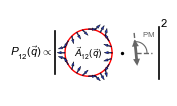

In [ ]:
print(f"For {str_journal} submission")

fig_Berry, axes_Berry = plt.subplots(1, 3, width_ratios = [1, 5, 2],
                                     figsize = plt_sizes["fig_Berryw_figsize"])
for ax in axes_Berry:
    ax.set_ylim(-0.8, 0.8)
    ax.axis("off")

# Normalize magnitudes into [0,1] for alpha
A_mag_finite = A_mag[np.isfinite(A_mag)]
if np.nanmax(A_mag_finite) > 0:
    alpha_vals = np.nan_to_num(A_mag / A_mag_finite.max(), nan = 0., posinf = 1., neginf = 1.)
else:
    alpha_vals = np.zeros_like(A_mag)

# Vector field plots
# Build RGBA colors with alpha = amplitude
base_color = (0.1, 0.2, 0.8)  # e.g. blue-ish
colors_rgba = np.zeros((len(A_mag), 4))
colors_rgba[:, 0] = base_color[0]
colors_rgba[:, 1] = base_color[1]
colors_rgba[:, 2] = base_color[2]
colors_rgba[:, 3] = alpha_vals**alpha_pwr

quiver_scale = dq / 0.02
qsets_scaled = qsets * plt_sizes["r_circ_scale"]
axes_Berry[1].quiver(
    qsets_scaled[::quiver_interval, 0], qsets_scaled[::quiver_interval, 1],
    A_plot[::quiver_interval, 0], A_plot[::quiver_interval, 1],
    color = colors_rgba,
    edgecolor = "black", linestyle = "-", linewidth = plt_sizes["quiver_lw"],
    angles = 'xy', scale_units = 'xy', scale = 10 * quiver_scale,
    width = 0.02 * quiver_scale,
    zorder = 100
)
util.draw_circle(axes_Berry[1], np.array([0, 0]), np.linalg.norm(qsets_scaled[0]),
                 color = "red", linewidth = plt_sizes["A12_circ_lw"])
axes_Berry[1].set_aspect('equal')
axes_Berry[1].set_xlim(-0.8, 0.8)
axes_Berry[1].text(0, 0, r"$\vec{A}_{12}(\vec{q})$",
                   fontsize = plt_sizes["A12_text_fontsize"], va = "center", ha = "center")

# Add definition of \theta_{PM}
color_theta_PM = "#666666"
hline_endpt = rq_circ * E9c.Mp4 / E9c.k_lw
theta_PM_example = 100 / 180 * np.pi    # Will look distorted because of the xlim and ylim, but don't have better solutions yet
theta_endpt = 0.6 * rq_circ * np.array([np.cos(theta_PM_example), np.sin(theta_PM_example)])
theta_arrow_endpt = 0.7 * theta_endpt
theta_stem_endpt = 0.4 * theta_endpt

axes_Berry[2].plot([0, hline_endpt[0]], [0, hline_endpt[1]],
           color = color_theta_PM, linestyle = "--", linewidth = 1)# plt_sizes["theta_PM_--lw"])
axes_Berry[2].plot([0, theta_endpt[0]], [0, theta_endpt[1]],
           color = color_theta_PM, linestyle = "--", linewidth = 1)#plt_sizes["theta_PM_--lw"])
# axes_Berry[2].text(0.07, 0.25, r"$\theta_{\mathrm{PM}}$", ha = "left", va = "bottom",
#                    color = color_theta_PM, fontsize = 8)#plt_sizes["theta_PM_fontsize"])
axes_Berry[2].text(0.20, 0.25, r"${}_{\mathrm{PM}}$", ha = "left", va = "bottom",
                   color = color_theta_PM, fontsize = 8)#add Symbol theta by hand
axes_Berry[2].plot([- theta_stem_endpt[0], theta_stem_endpt[0]], [- theta_stem_endpt[1], theta_stem_endpt[1]],
           color = color_theta_PM, linestyle = "-", linewidth = 2)
arrow_PM = FancyArrowPatch(
                theta_arrow_endpt,
                -theta_arrow_endpt,
                edgecolor = "none",         # This smoothes out the arrow
                facecolor = color_theta_PM,
                arrowstyle = '<|-|>,head_width=0.05,head_length=0.10',#plt_sizes["PM_arrow_arrowstyle"],
                mutation_scale = 50,
                shrinkA = 0,
                shrinkB = 0
            )
axes_Berry[2].add_patch(arrow_PM)
util.draw_circle(axes_Berry[2], center = (0, 0), radius = 11, theta_range = (0, theta_PM_example),
                 close_circle = False, color = color_theta_PM, linestyle = "-", coor_type = "display",
                 linewidth = 0.8)#plt_sizes["theta_PM_arclw"])

# other small stuff (text etc.)
axes_Berry[0].text(0, 0, r"$P_{12}(\vec{q}) \propto$",
                   fontsize = 8, va = "center", ha = "center")
axes_Berry[1].axvline(x = -0.75, ymin = 0.2, ymax = 0.8, linewidth = 1.2, color = "black", clip_on = False)
axes_Berry[2].axvline(x = 0.8, ymin = 0.2, ymax = 0.8, linewidth = 1.2, color = "black", clip_on = False)
axes_Berry[2].text(0.83, 0.45, r"$2$", fontsize = 8, va = "bottom", ha = "left")
axes_Berry[2].scatter(-0.5, 0, s = 2, color = "black", clip_on = False)
axes_Berry[2].set_xlim(-0.15, 0.85)
axes_Berry[2].plot([],[])

fig_Berry.tight_layout(pad = 0)

fig2av2path = Path(r"C:\Users\ken92\Documents\Studies\E5\simulation\E9_simulations\projects\band_spectroscopy\paper_figures\fig2",
                 f"fig2a_v2_{str_journal}.pdf")
# fig_Berry.savefig(fig2av2path, format = "pdf", facecolor = "none", dpi = 300, bbox_inches = 'tight')

## Linear shaking

In [23]:
# Angles of shaking used in the interband Berry connection paper
# theta_deg_init = -160
# theta_deg_lin_PM = theta_deg_init + 160 * np.linspace(0, 1, num = 9)
theta_deg_lin_PM = 180 * np.linspace(-1, 0, num = 100)    # Angles of shaking
bool_flip_in_y = True   # I think this is needed because of our orientation of camera

Maximum deviation from the theory is 6.875 degrees


Text(0.5, 0.98, 'Nodal line angular position from plane wave expansion')

INFO:matplotlib.mathtext:Substituting symbol \cdot from Computer Modern
INFO:matplotlib.mathtext:Substituting symbol \cdot from Computer Modern


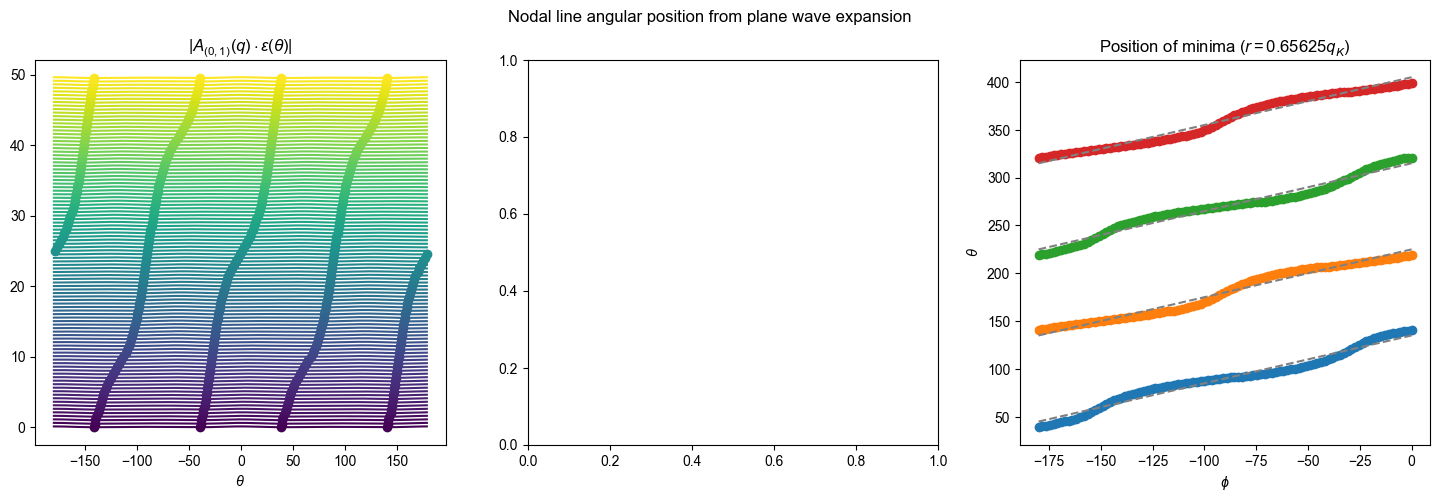

In [24]:
theta_min_ME = np.full((len(theta_deg_lin_PM), 4), np.nan)                  # This assumes four nodes
theta_deviation = np.full((len(theta_deg_lin_PM), 4), np.nan)               # Deviation from the theory curve
fig_lin_PM, axes_lin_PM = plt.subplots(1, 3, figsize=(18, 5))

theta_xq = np.arctan2(qsets[:,1], qsets[:,0]) *  180 / np.pi
for i, theta in enumerate(theta_deg_lin_PM):
    vec_PM = np.array([np.cos(theta / 180 * np.pi), np.sin(theta / 180 * np.pi) * (-1)**int(bool_flip_in_y)])
    ME2_Fermi = np.abs(A_Berry @ vec_PM)**2     # Proportional to matrix element squared
    ME2_Fermi = np.nan_to_num(ME2_Fermi, nan = 0., posinf = 1.)
    ME2_Fermi_mn00 = ME2_Fermi * (1 - mn00_ratio_band10)
    idxs_min = util.find_local_minima(ME2_Fermi, wrap = True)

    theta_min_ME[i, :] = theta_xq[idxs_min]
    ME2_Fermi_offset = ME2_Fermi + 0.5 * i

    color = util.get_color(theta, theta_deg_lin_PM)
    axes_lin_PM[0].plot(theta_xq, ME2_Fermi_offset, color = color, label = f"{theta:.1f}")
    axes_lin_PM[0].scatter(theta_xq[idxs_min], ME2_Fermi_offset[idxs_min], color = color)

# align the points and match it to experiment convention by hand
sgn_y_conv = (-1)**int(bool_flip_in_y)
idx_phase_jump = int(len(theta_deg_lin_PM) / 2)
theta_min_ME[idx_phase_jump:,:] = np.roll(                  # to make the top line continuous
    theta_min_ME[idx_phase_jump:,:], sgn_y_conv, axis = 1)
theta_min_ME[:, (0,1)] += 360.
theta_min_ME = np.roll(theta_min_ME, 2, axis = 1)
theta_min_ME = np.unwrap(theta_min_ME, axis = 1, period = 360.)

# theory plot
for i in range(4):
    # theta_th = -theta_deg_lin_PM / 2 + i * 90 - 45
    theta_th = -sgn_y_conv * (theta_deg_lin_PM / 2 + 180) + i * 90 - 45
    axes_lin_PM[2].plot(theta_deg_lin_PM, theta_th, ls = "--", color = "grey")
    axes_lin_PM[2].scatter(theta_deg_lin_PM, theta_min_ME[:, i])
    # axes_lin_PM[2].plot(theta_deg_lin_PM, theta_min_ME[:, i])
    theta_deviation[:, i] = ((theta_min_ME[:, i] - theta_th) + 180) % 360 - 180
    
print(f"Maximum deviation from the theory is {theta_deviation.max():.3f} degrees")

# axes_lin_PM[0].legend()
axes_lin_PM[0].set_title(rf"$|A_{{{i_Berry}}}(q) \cdot \epsilon(\theta)|$")
axes_lin_PM[0].set_xlabel(r"$\theta$")
axes_lin_PM[2].set_title(rf"Position of minima ($r = {rq_circ} q_K$)")
axes_lin_PM[2].set_xlabel(r"$\phi$")
axes_lin_PM[2].set_ylabel(r"$\theta$")
fig_lin_PM.suptitle("Nodal line angular position from plane wave expansion")

In [25]:
A_node_str = f"node_position_band{i_Berry[0]}{i_Berry[1]}_lw{V1064nom:.2f}kHz_rq{rq_circ}qK_sgn_y_conv{sgn_y_conv}.npz"
A_node_save_path = Path(r"C:\Users\ken92\Documents\Studies\E5\simulation\E9_simulations\projects\band_spectroscopy\paper_figures\fig2", A_node_str)
print(A_node_save_path)
# np.savez(A_node_save_path, theta_deg_lin_PM = theta_deg_lin_PM, theta_min_ME = theta_min_ME)

C:\Users\ken92\Documents\Studies\E5\simulation\E9_simulations\projects\band_spectroscopy\paper_figures\fig2\node_position_band01_lw39.50kHz_rq0.65625qK_sgn_y_conv-1.npz


# Quantum metric tensor (Ignore for now)

In [26]:
bool_find_QMT = False

In [27]:
if bool_find_QMT:
    qgts_xx = np.zeros((len(qsets), bandnum), dtype = np.cdouble)
    for i in range(len(qsets)):
        for j in range(bandnum):
            qgts_xx[i, j] = bsc.find_q_geo_tensor(i, j, Exp_lib, qsets, e_values, e_states, Hq_mmat, Hq_nmat)
    qmts_xx = np.real(qgts_xx)                # quantum metric tensor
    berry_curvs_xx = - 2 * np.imag(qgts_xx)   # Berry curvature

    fig_qgt = plt.figure(2, figsize=(10,7))
    fig_qgt.clf()
    ax_qgt = fig_qgt.add_subplot(111)
    ax_qgt.set_title('Quantum geometric tensor')
    ax_qgt.plot(xq, qmts_xx[:, 2], label = 'qmts_00')